# Regression Model

In this notebook:

- stationary transformations (based on EDA)
- comparision of different OLS models with varying lag structures
- final model diagnostics: *multicollinearity (VIF), residual normality (QQ), influential obs (Cook's distance), robust SE (HC3)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

In [2]:
df = pd.read_excel("../../data_processed/quarterly_data.xlsx")
df = df.drop(columns=["ROE"]) 
df_fe = df.copy()

df_fe.tail()

,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital
27,2023Q4,5.166667,36.907833,15.666667,0.052,37.351358,21.07,3.24,1024678.0,296044.0
28,2024Q1,4.066667,38.434567,14.833333,0.068,36.066158,20.44,5.45,1041062.0,339093.0
29,2024Q2,3.766667,40.235433,13.333333,0.040,34.570918,19.07,5.28,1087350.0,354533.0
30,2024Q3,7.166667,41.128533,13.000000,0.022,32.336924,19.85,5.14,1134872.0,391882.0
31,2024Q4,10.966667,41.637867,13.166667,-0.001,30.288271,17.35,2.94,1138032.0,368348.0


## Stationary trasfromations

1) log-difference: `capital`, `usd_uah`, `loans`
2) first-order difference: `NPL`, `CAR`, `ROA` 
3) leave unchanged: `CPI`, `gdp_growth`, `policy_rate`

In [3]:
# 1. log-difference
df_fe["capital_growth"] = np.log(df_fe["capital"]).diff()
df_fe["fx_change"] = np.log(df_fe["usd_uah"]).diff()
df_fe["loan_growth"] = np.log(df_fe["loans"]).diff()
df_fe["policy_rate_growth"] = np.log(df_fe["policy_rate"]).diff()

# 2. first difference
df_fe["d_NPL"] = df_fe["NPL"].diff()
df_fe["d_CAR"] = df_fe["CAR"].diff()
df_fe["d_ROA"] = df_fe["ROA"].diff()


display(
    df_fe[
        [
            "date",
            "capital_growth",
            "fx_change",
            "loan_growth",
            "d_NPL",
            "d_CAR",
            "d_ROA",
            "CPI",
            "gdp_growth",
            "policy_rate"
        ]
    ].head(8)
)

,date,capital_growth,fx_change,loan_growth,d_NPL,d_CAR,d_ROA,CPI,gdp_growth,policy_rate
0,2017Q1,NaN,NaN,NaN,NaN,NaN,NaN,13.966667,0.028,14.000000
1,2017Q2,-0.084670,-0.026795,-0.013066,2.626724,-1.30,-1.91,13.766667,0.027,12.666667
2,2017Q3,0.183261,-0.012572,0.019625,-1.297114,2.85,0.42,16.166667,0.023,12.500000
3,2017Q4,-0.046320,0.048711,0.044062,-1.894336,0.83,-2.08,13.966667,0.022,13.833333
4,2018Q1,-0.012661,-0.005019,0.022073,1.904854,0.39,4.59,13.766667,0.035,16.333333
5,2018Q2,-0.107975,-0.036809,-0.002373,-0.769964,-0.05,-1.39,11.566667,0.039,17.000000
6,2018Q3,0.010262,0.059044,0.081564,-1.369133,-0.71,-0.16,8.933333,0.027,17.666667
7,2018Q4,0.071467,0.010869,-0.025040,-1.459476,0.45,0.58,9.766667,0.037,18.000000


In [4]:
df_fe[df_fe.isna().any(axis=1)]

,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital,capital_growth,fx_change,loan_growth,policy_rate_growth,d_NPL,d_CAR,d_ROA
0,2017Q1,13.966667,27.049589,14.0,0.028,55.106022,13.72,1.64,985570.0,152903.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2022Q1,11.466667,29.097900,10.0,-0.146,27.064749,NaN,-0.03,1070449.0,208105.0,-0.205234,0.077566,0.004778,0.143101,-2.957951,NaN,-4.12
21,2022Q2,18.633333,29.254900,15.0,-0.366,29.712683,17.16,-0.46,1055583.0,230746.0,0.103275,0.005381,-0.013985,0.405465,2.647935,NaN,-0.43


## Build & Compare different regression models

In [20]:
df_lag = df_fe.copy()

lag_vars = ["gdp_growth", "policy_rate", "fx_change", "CPI", "loan_growth", "d_NPL", "policy_rate_growth"]

for var in lag_vars:
    for lag in range(1, 5):
        df_lag[f"{var}_lag{lag}"] = df_lag[var].shift(lag)      

target = "d_NPL"

# Models

specifications = {
    "Model 1: contemporaneous": [
        "gdp_growth",
        "policy_rate",
        "fx_change"
    ],
    
    "Model 2: one-quarter lagged": [
        "gdp_growth_lag1",
        "policy_rate_lag1",
        "fx_change_lag1"
    ],
    
    "Model 2 + loans_lag1": [
        "gdp_growth_lag1",
        "policy_rate_lag1",
        "fx_change_lag1",
        "loan_growth_lag1" 
    ],
    
    "Model 2 + NPL_lag1": [
        "gdp_growth_lag1",
        "policy_rate_lag1",
        "fx_change_lag1",
        "loan_growth",
        "d_NPL_lag1"
        
    ],

    "Model 2 + log(policy_rate)": [
        "gdp_growth_lag1",
        "policy_rate_growth_lag1",
        "fx_change_lag1"
    ],
    
    "Model 2 + log(policy_rate) + NPL_lag1":  [
        "gdp_growth_lag1",
        "policy_rate_growth_lag1",
        "fx_change_lag1",
        "d_NPL_lag1"
    ],
    
    "Model 3: two-quarter lagged": [
        "gdp_growth_lag2",
        "policy_rate_lag2",
        "fx_change_lag2"
    ],
    
    "Model 4: mixed lag": [
        "gdp_growth_lag1",
        "policy_rate_lag1",
        "fx_change"
    ],
    
    "Model 5: lagged model with CPI": [
        "gdp_growth_lag1",
        "policy_rate_lag1",
        "fx_change_lag1",
        "CPI_lag1"
    ]
}


def estimate_ols_model(data, features, target):
    model_data = data[features + [target]].dropna()
    
    X = model_data[features]
    y = model_data[target]
    
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    return model, model_data

# Estimate all specifications and compare results

model_results = {}
comparison_rows = []

for model_name, features in specifications.items():
    model, model_data = estimate_ols_model(df_lag, features, target)
    
    model_results[model_name] = {
        "model": model,
        "data": model_data,
        "features": features
    }
    
    comparison_rows.append({
        "model": model_name,
        "n_obs": int(model.nobs),
        "const": model.params.get("const"),
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "aic": model.aic, # Akaike Information Criterion
        "bic": model.bic, # Bayesian Information Criterion
        "f_pvalue": model.f_pvalue
    })

comparison_table = pd.DataFrame(comparison_rows)

comparison_table = comparison_table.sort_values(
    by="adj_r_squared",
    ascending=False
)

display(comparison_table.round(4))

,model,n_obs,const,r_squared,adj_r_squared,aic,bic,f_pvalue
3,Model 2 + NPL_lag1,30,-3.7910,0.6572,0.5858,107.8439,116.2511,0.0001
0,Model 1: contemporaneous,31,-3.8832,0.6113,0.5682,112.7875,118.5235,0.0000
1,Model 2: one-quarter lagged,30,-3.2663,0.6063,0.5608,108.0003,113.6051,0.0000
2,Model 2 + loans_lag1,30,-3.2960,0.6085,0.5459,109.8305,116.8365,0.0001
8,Model 5: lagged model with CPI,30,-3.2819,0.6073,0.5445,109.9210,116.9270,0.0001
5,Model 2 + log(policy_rate) + NPL_lag1,30,-0.8694,0.5698,0.5010,112.6573,119.6633,0.0002
4,Model 2 + log(policy_rate),30,-1.1183,0.5132,0.4570,114.3671,119.9719,0.0003
7,Model 4: mixed lag,31,-3.1779,0.5000,0.4444,120.5980,126.3340,0.0003
6,Model 3: two-quarter lagged,29,-1.9893,0.2092,0.1144,125.8377,131.3069,0.1125


> Model 2 is selected for the further analysis. This model is also considered to be a common practice in stress-testing. 

## Final model & its diagnostics

In [6]:
# Final baseline model

baseline_features =  [
        "gdp_growth_lag1",
        "policy_rate_lag1",
        "fx_change_lag1",
        "loan_growth_lag1" 
    ]

target = "d_NPL"

baseline_data = df_lag[baseline_features + [target, "date"]].dropna()

X_baseline = baseline_data[baseline_features]
y_baseline = baseline_data[target]

X_baseline = sm.add_constant(X_baseline)

baseline_model = sm.OLS(y_baseline, X_baseline).fit()

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_NPL   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     9.714
Date:                Tue, 26 May 2026   Prob (F-statistic):           6.98e-05
Time:                        01:20:09   Log-Likelihood:                -49.915
No. Observations:                  30   AIC:                             109.8
Df Residuals:                      25   BIC:                             116.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.2960      0.710  

In [7]:
baseline_data = baseline_data.copy()

baseline_data["fitted_d_NPL"] = baseline_model.fittedvalues
baseline_data["residuals"] = baseline_model.resid

display(baseline_data.head())

,gdp_growth_lag1,policy_rate_lag1,fx_change_lag1,loan_growth_lag1,d_NPL,date,fitted_d_NPL,residuals
2,0.027,12.666667,-0.026795,-0.013066,-1.297114,2017Q3,-1.895736,0.598622
3,0.023,12.500000,-0.012572,0.019625,-1.894336,2017Q4,-1.682763,-0.211573
4,0.022,13.833333,0.048711,0.044062,1.904854,2018Q1,-0.977185,2.882040
5,0.035,16.333333,-0.005019,0.022073,-0.769964,2018Q2,-1.163029,0.393065
6,0.039,17.000000,-0.036809,-0.002373,-1.369133,2018Q3,-1.397401,0.028268


### Actual vs fitted values

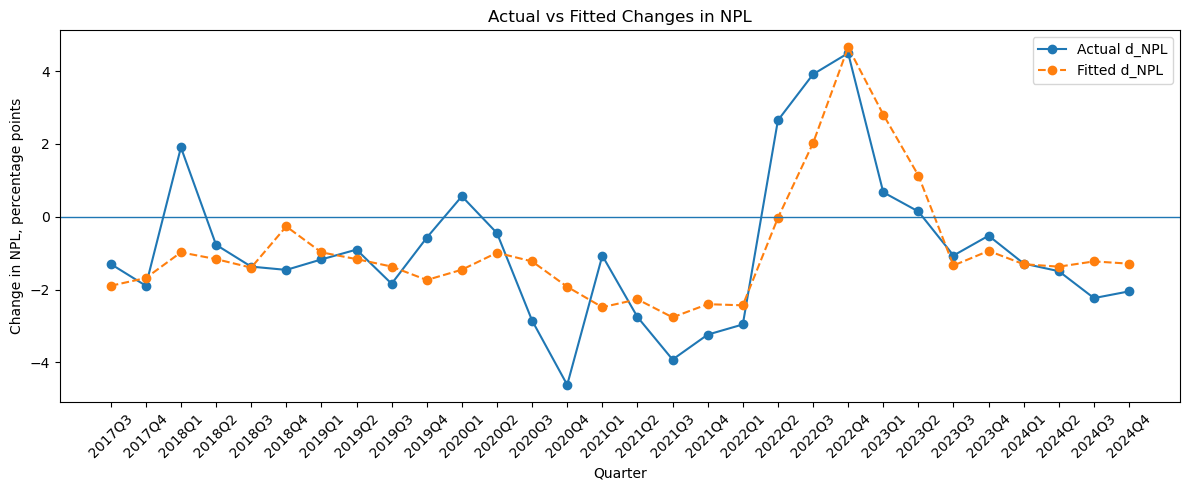

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    baseline_data["date"],
    baseline_data["d_NPL"],
    marker="o",
    label="Actual d_NPL"
)

plt.plot(
    baseline_data["date"],
    baseline_data["fitted_d_NPL"],
    marker="o",
    linestyle="--",
    label="Fitted d_NPL"
)

plt.axhline(0, linewidth=1)

plt.title("Actual vs Fitted Changes in NPL")
plt.xlabel("Quarter")
plt.ylabel("Change in NPL, percentage points")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Autocorrelation diagnostics

In [9]:
bg_test = acorr_breusch_godfrey(model, nlags=1)

print("LM statistic:", round(bg_test[0], 4))
print("LM p-value:", round(bg_test[1], 4))
print("F statistic:", round(bg_test[2], 4))
print("F p-value:", round(bg_test[3], 4))

LM statistic: 2.2053
LM p-value: 0.1375
F statistic: 1.9043
F p-value: 0.1803


### Residual plot

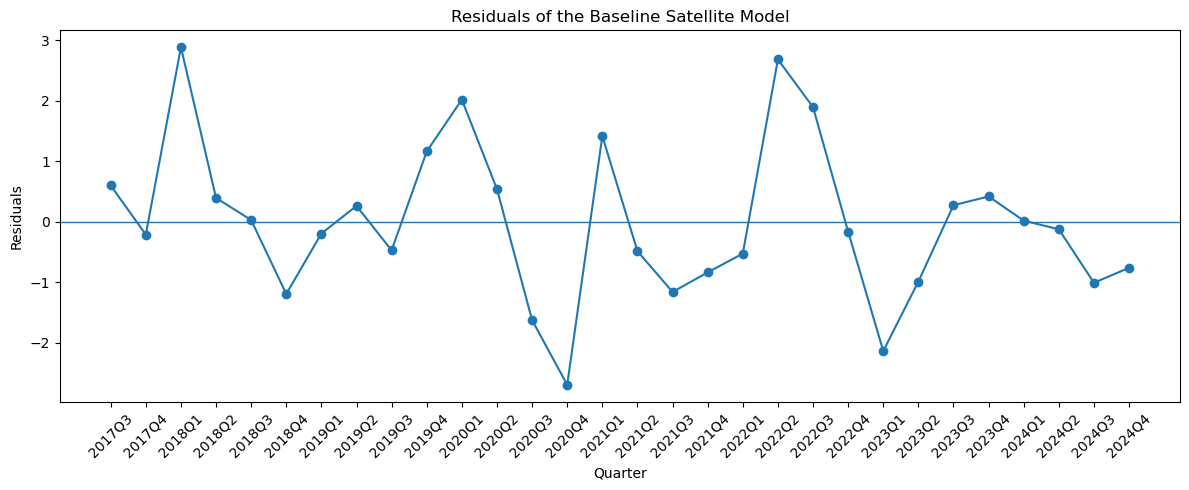

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    baseline_data["date"],
    baseline_data["residuals"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Residuals of the Baseline Satellite Model")
plt.xlabel("Quarter")
plt.ylabel("Residuals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Multicollinearity diagnostics: VIF (Variance Inflation Factor)

In [11]:
X_vif = X_baseline.copy()

vif_table = pd.DataFrame()
vif_table["variable"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_table.round(3))

,variable,VIF
0,const,7.727
1,gdp_growth_lag1,1.594
2,policy_rate_lag1,1.042
3,fx_change_lag1,1.729
4,loan_growth_lag1,1.464


> The VIF results indicate very low multicollinearity among the explanatory variables.Therefore, the regression coefficients can be interpreted with a reasonable degree of stability and reliability.

### Robust standard errors diagnostics (HC3)

Recalculate standard errors for more reliable p-values

In [12]:
baseline_model_hc3 = baseline_model.get_robustcov_results(cov_type="HC3")

print(baseline_model_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_NPL   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     12.80
Date:                Tue, 26 May 2026   Prob (F-statistic):           8.37e-06
Time:                        01:20:10   Log-Likelihood:                -49.915
No. Observations:                  30   AIC:                             109.8
Df Residuals:                      25   BIC:                             116.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.2960      1.004  

### Residual normality diagnostics (QQ plot) 

The QQ plot is used to visually assess the normality of regression residuals. If residuals are approximately normally distributed, the points should lie close to the 45-degree reference line. Deviations in the tails may indicate the presence of outliers or crisis-related observations.

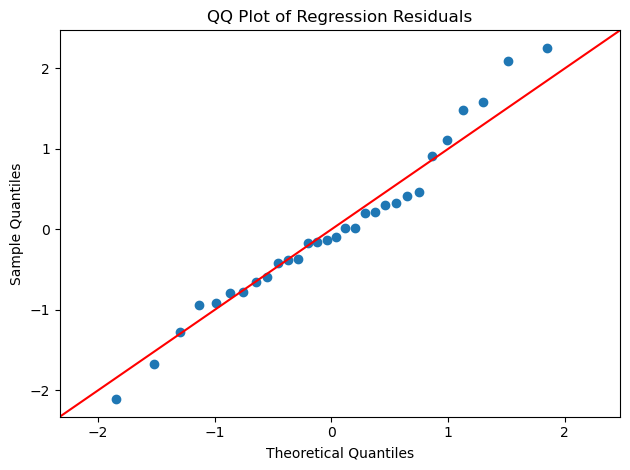

In [13]:
sm.qqplot(baseline_data["residuals"], line="45", fit=True)
plt.title("QQ Plot of Regression Residuals")
plt.tight_layout()
plt.show()

>The QQ plot indicates that the regression residuals are approximately normally distributed.

### Influence diagnostics (Cook's distance)

In [14]:
influence = baseline_model.get_influence()

influence_table = baseline_data.copy()

influence_table["standardized_residuals"] = influence.resid_studentized_internal
influence_table["cooks_distance"] = influence.cooks_distance[0]
influence_table["leverage"] = influence.hat_matrix_diag

display(
    influence_table[
        [
            "date",
            "d_NPL",
            "fitted_d_NPL",
            "residuals",
            "standardized_residuals",
            "cooks_distance",
            "leverage"
        ]
    ].round(4)
)

,date,d_NPL,fitted_d_NPL,residuals,standardized_residuals,cooks_distance,leverage
2,2017Q3,-1.2971,-1.8957,0.5986,0.4410,0.0025,0.0593
3,2017Q4,-1.8943,-1.6828,-0.2116,-0.1559,0.0003,0.0594
4,2018Q1,1.9049,-0.9772,2.8820,2.1462,0.0793,0.0792
5,2018Q2,-0.7700,-1.1630,0.3931,0.2895,0.0010,0.0587
6,2018Q3,-1.3691,-1.3974,0.0283,0.0210,0.0000,0.0784
7,2018Q4,-1.4595,-0.2658,-1.1937,-0.9545,0.0460,0.2014
8,2019Q1,-1.1719,-0.9775,-0.1944,-0.1462,0.0005,0.0974
9,2019Q2,-0.9021,-1.1632,0.2611,0.1940,0.0006,0.0751
10,2019Q3,-1.8397,-1.3680,-0.4717,-0.3498,0.0019,0.0718
11,2019Q4,-0.5755,-1.7371,1.1616,0.8953,0.0262,0.1404


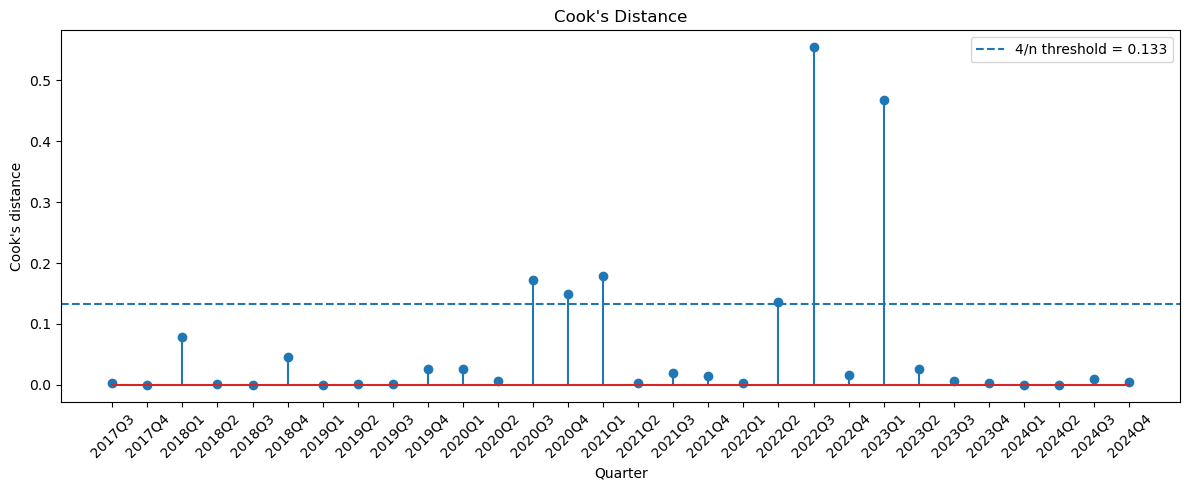

In [15]:
# Cook's distance plot

cooks_threshold = 4 / len(influence_table)

plt.figure(figsize=(12, 5))
plt.stem(
    influence_table["date"].astype(str),
    influence_table["cooks_distance"]
)

plt.axhline(
    cooks_threshold,
    linestyle="--",
    label=f"4/n threshold = {cooks_threshold:.3f}"
)

plt.title("Cook's Distance")
plt.xlabel("Quarter")
plt.ylabel("Cook's distance")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

> The height of each line indicates how strongly a particular observation influences the regression coefficients. It can be seen that 2020Q4, 2022Q2, 2022Q3, and 2023Q1 have the highest Cook’s distance values. However, each of these observations has a clear economic explanation related to delayed COVID-19 and war effects.

### Robustness check

In [16]:
robustness_specs = {
    "Full sample": df_lag.copy(),

    "Excluding COVID period": df_lag[
        ~df_lag["date"].between("2020-01-01", "2020-12-31")
    ].copy(),

    "Excluding full-scale war period": df_lag[
        df_lag["date"] < "2022-01-01"
    ].copy(),

    "Excluding COVID and war periods": df_lag[
        (~df_lag["date"].between("2020-01-01", "2020-12-31")) &
        (df_lag["date"] < "2022-01-01")
    ].copy(),

    "Excluding selected crisis quarters": df_lag[
        ~df_lag["date"].isin([
            pd.Timestamp("2020-04-01"),  
            pd.Timestamp("2020-07-01"),  
            pd.Timestamp("2022-04-01"),  
            pd.Timestamp("2022-07-01"),  
            pd.Timestamp("2022-10-01")   
        ])
    ].copy()
}

baseline_features = [
    "gdp_growth_lag1",
    "policy_rate_lag1",
    "fx_change_lag1"
]

target = "d_NPL"

robustness_rows = []

for sample_name, sample_df in robustness_specs.items():
    model, model_data = estimate_ols_model(
        sample_df,
        baseline_features,
        target
    )

    row = {
        "sample": sample_name,
        "n_obs": int(model.nobs),
        "const": model.params.get("const", np.nan),
        "gdp_growth_lag1": model.params.get("gdp_growth_lag1", np.nan),
        "policy_rate_lag1": model.params.get("policy_rate_lag1", np.nan),
        "fx_change_lag1": model.params.get("fx_change_lag1", np.nan),
        "adj_r_squared": model.rsquared_adj,
        "aic": model.aic,
        "bic": model.bic,
        "f_pvalue": model.f_pvalue
    }

    robustness_rows.append(row)

robustness_table = pd.DataFrame(robustness_rows)

robustness_table

,sample,n_obs,const,gdp_growth_lag1,policy_rate_lag1,fx_change_lag1,adj_r_squared,aic,bic,f_pvalue
0,Full sample,30,-3.266268,-8.081315,0.144870,8.205580,0.560843,108.000286,113.605076,0.000018
1,Excluding COVID period,30,-3.266268,-8.081315,0.144870,8.205580,0.560843,108.000286,113.605076,0.000018
2,Excluding full-scale war period,18,-4.178607,0.444616,0.209228,10.141265,0.243703,65.502838,69.064325,0.076858
3,Excluding COVID and war periods,18,-4.178607,0.444616,0.209228,10.141265,0.243703,65.502838,69.064325,0.076858
4,Excluding selected crisis quarters,30,-3.266268,-8.081315,0.144870,8.205580,0.560843,108.000286,113.605076,0.000018


In [17]:
# Save dataset

baseline_data = df_lag[[
    "date",
    "NPL",
    "d_NPL",
    "gdp_growth_lag1",
    "policy_rate_lag1",
    "fx_change_lag1"
]].dropna().copy()

X_baseline = sm.add_constant(baseline_data[baseline_features])
y_baseline = baseline_data["d_NPL"]

baseline_model = sm.OLS(y_baseline, X_baseline).fit()

baseline_data["fitted_d_NPL"] = baseline_model.fittedvalues
baseline_data["residuals"] = baseline_model.resid

baseline_data.to_excel(
    "../../data_processed/regression_dataset.xlsx",
    index=False
)